# Lock-in ODMR: from slow DC sweeps to fast AM/FM detection

**A tutorial for new lab members — no signal-processing background required.**

In our lab we measure ODMR (Optically Detected Magnetic Resonance) of NV centres in
diamond. The setup is simple:

* a **R&S SMCV100B** generates microwaves (→ amplifier → antenna above the diamond),
* a green laser continuously excites the NV centres,
* a photodiode watches the red photoluminescence (PL) and feeds a **Red Pitaya**
  fast ADC (IN1).

When the microwave frequency hits an NV spin resonance (~2.87 GHz), the PL drops by
a percent or two. Sweeping the microwave frequency and recording PL gives the ODMR
spectrum: a few narrow dips whose positions encode the magnetic field.

We have three ways of taking that spectrum, implemented in `smcv/`:

| Script | Method | Time per point |
|---|---|---|
| `odmr_smcv100b_pc.py` | **DC**: step frequency, average PL for 100 ms | ~200 ms (incl. MW-off reference) |
| `odmr_lockin_am_pc.py` | **AM lock-in**: modulate MW *amplitude* at 5 kHz | ~8 ms |
| `odmr_lockin_fm_pc.py` | **FM lock-in**: modulate MW *frequency* at 5 kHz | ~8 ms |

The lock-in versions are ~25× faster per point *and* less noisy. That sounds like
cheating. This notebook explains, step by step, why it is not:

1. **Part 1 — DC ODMR**: how the conventional measurement works, and how noise limits it.
2. **Part 2 — Amplitude modulation**: tag the signal with a 5 kHz label, then listen
   only at 5 kHz.
3. **Part 3 — Frequency modulation**: wiggle the frequency and measure the *slope*
   of the resonance.

Everything below is simulation — you can run it on any laptop, change the numbers,
and break things safely. The simulation parameters mirror our real `config.json`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
rng = np.random.default_rng(7)          # fixed seed -> reproducible figures

# ---- physics of our sample (mirrors analysis/nv_odmr_sim.py, simplified) ----
V0       = 1.0      # photodiode voltage far from resonance [V]
CONTRAST = 0.02     # ODMR contrast: 2 % dip at full MW power
FWHM     = 1.5      # linewidth [MHz]
CENTERS  = (2865.0, 2875.0)   # one NV orientation, split by a small field
                              # (10 MHz split = 2*gamma*B_par, B_par ~ 0.18 mT)

# ---- sweep & modulation settings (mirrors smcv/config.json) ----
F_START, F_STOP, F_STEP = 2850.0, 2900.0, 0.25   # MHz (real setup: 0.1 MHz step)
F_MOD    = 5_000.0   # modulation frequency [Hz]      (config: lockin.f_mod_hz)
AM_DEPTH = 0.90      # AM modulation depth m          (config: am_depth_pct = 90)
FM_DEV   = 0.75      # FM frequency deviation [MHz]   (config uses 2.0 -- see Part 3)

FREQS = np.arange(F_START, F_STOP + 1e-9, F_STEP)
print(f"{len(FREQS)} frequency points from {F_START} to {F_STOP} MHz")

201 frequency points from 2850.0 to 2900.0 MHz


## The ideal spectrum (what we are trying to measure)

The PL dip at each resonance is well described by a **Lorentzian**. With microwaves
at relative power $p$ (0 = off, 1 = full), the photodiode voltage is

$$V(f) \;=\; V_0\,\bigl[\,1 - C(f)\, p\,\bigr],
\qquad
C(f) = C_0 \sum_{i} \frac{(\Gamma/2)^2}{(f - f_i)^2 + (\Gamma/2)^2}$$

with contrast $C_0 = 2\%$, linewidth $\Gamma = 1.5$ MHz and two lines $f_i$
(one NV orientation, Zeeman-split by a small magnet). $C(f)\,p$ is the *fractional*
PL suppression: assuming it scales linearly with MW power is a good approximation
below saturation, and it is all we need here.

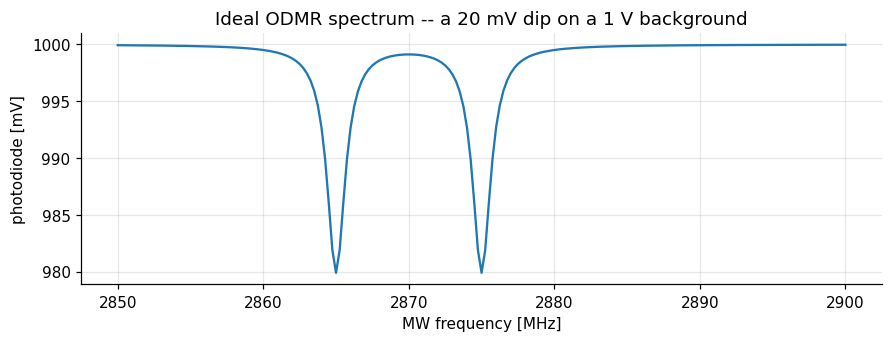

In [2]:
def lorentzian(f, c, fwhm=FWHM):
    hw = fwhm / 2.0
    return hw**2 / ((f - c)**2 + hw**2)

def contrast(f):
    '''Fractional PL suppression C(f) at full MW power.'''
    f = np.asarray(f, dtype=float)
    return CONTRAST * sum(lorentzian(f, c) for c in CENTERS)

def pl_volt(f, p=1.0):
    '''Ideal (noise-free) photodiode voltage with relative MW power p.'''
    return V0 * (1.0 - contrast(f) * p)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(FREQS, 1e3 * pl_volt(FREQS), color="C0")
ax.set(xlabel="MW frequency [MHz]", ylabel="photodiode [mV]",
       title="Ideal ODMR spectrum -- a 20 mV dip on a 1 V background")
plt.show()

> **EXPERIMENT.** The same thing measured on our rig with
`smcv/odmr_smcv100b_pc.py` (the conventional DC method, 100 ms/point, MW-on/off
normalised, several sweeps averaged). Point `DC_ODMR_FILE` at any of your runs.

In [3]:
# === EXPERIMENT: a measured DC ODMR spectrum ===============================
import csv, os

DC_ODMR_FILE = r"C:\Users\qute\Downloads\rsattempt\08-07-2026\odmr_average.csv"  # <-- edit me

if not os.path.exists(DC_ODMR_FILE):
    print(f"File not found: {DC_ODMR_FILE!r}\n"
          "Edit DC_ODMR_FILE above to point at one of your odmr_average.csv "
          "or odmr_runs/run_XX.csv files.")
else:
    fx, vy = [], []
    with open(DC_ODMR_FILE) as fh:
        for row in csv.reader(fh):
            if not row or row[0].startswith("#") or row[0].startswith("freq"):
                continue
            fx.append(float(row[0])); vy.append(float(row[1]))
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(fx, vy, lw=0.9, color="C0")
    ax.set(xlabel="MW frequency [MHz]",
           ylabel="signal (PL$_{on}$/PL$_{off}$ or V)",
           title="EXPERIMENT: DC ODMR -- " + os.path.basename(DC_ODMR_FILE))
    plt.show()

File not found: 'C:\\Users\\qute\\Downloads\\rsattempt\\08-07-2026\\odmr_average.csv'
Edit DC_ODMR_FILE above to point at one of your odmr_average.csv or odmr_runs/run_XX.csv files.


## The enemy: what noise actually looks like

If the photodiode voltage were exactly the curve above, one instantaneous sample per
frequency would be enough. In reality the trace is buried in noise, and — this is
the central point of the whole notebook — **noise is not equally strong at all
frequencies**. Our (and almost every) optics experiment has three ingredients:

* **White noise** — photon shot noise, amplifier/ADC noise. Flat: the same power at
  every frequency. Unavoidable, but benign.
* **$1/f$ ("flicker") noise + drift** — laser intensity wander, temperature,
  mechanical creep, electronics. Power grows as you go toward 0 Hz. This is the
  noise that makes traces "wander" on second-to-minute timescales.
* **Mains pickup** — sharp spikes at 50 Hz and harmonics from the power grid.

We model the noise by its **power spectral density** (PSD) $S(f)$ — noise power per
1 Hz of bandwidth:

$$S(f) = w^2\Bigl(1 + \frac{f_k}{f}\Bigr) \;+\; \text{mains spikes},$$

a flat floor $w^2$ with a $1/f$ ramp below the "knee" $f_k$. A key fact we will use
constantly: if you only look at a frequency band of width $B$, the noise you see has
RMS amplitude $\sqrt{\int_B S(f)\,df}$ — **only the noise inside your band counts**.

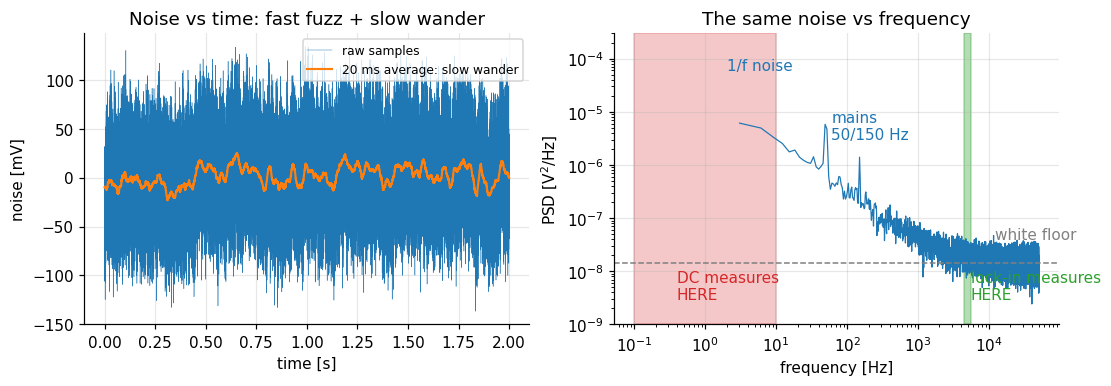

In [4]:
W_ASD  = 1.2e-4   # white-noise amplitude spectral density [V / sqrt(Hz)]
F_KNEE = 2_000.0  # 1/f knee [Hz]: below this, 1/f noise dominates the white floor
MAINS  = ((50.0, 8e-3), (150.0, 3e-3))   # (frequency [Hz], amplitude [V])

def make_noise(n, fs, rng, w=W_ASD, f_knee=F_KNEE, mains=MAINS):
    '''n samples of realistic detector noise at sample rate fs [Hz].

    White Gaussian noise is shaped in the frequency domain so its PSD becomes
    w^2 * (1 + f_knee/f); coherent mains tones are added with random phase.'''
    x = rng.standard_normal(n) * w * np.sqrt(fs / 2.0)   # white, PSD = w^2
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(n, 1.0 / fs)
    f[0] = f[1] if n > 1 else 1.0                        # avoid divide-by-zero at DC
    y = np.fft.irfft(X * np.sqrt(1.0 + f_knee / f), n)   # sculpt the 1/f ramp
    t = np.arange(n) / fs
    for fm, am in mains:
        y += am * np.sin(2 * np.pi * fm * t + rng.uniform(0, 2 * np.pi))
    return y

# --- look at 2 s of noise, in time and in frequency ---
fs = 100_000
v = make_noise(2 * fs, fs, rng)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
tv = np.arange(len(v)) / fs
ax1.plot(tv, 1e3 * v, lw=0.3, color="C0", label="raw samples")
kern = int(0.02 * fs)                                    # 20 ms moving average
ax1.plot(tv, 1e3 * np.convolve(v, np.ones(kern) / kern, "same"),
         color="C1", lw=1.4, label="20 ms average: slow wander")
ax1.legend(fontsize=8, loc="upper right")
ax1.set(xlabel="time [s]", ylabel="noise [mV]", title="Noise vs time: fast fuzz + slow wander")

# PSD estimate (Welch's method: average the spectra of many short segments)
from scipy.signal import welch
fr, S = welch(v, fs=fs, nperseg=1 << 15)
ax2.loglog(fr[1:], S[1:], lw=0.8, color="C0")
ax2.axhline(W_ASD**2, color="gray", ls="--", lw=1)
ax2.axvspan(0.1, 10, color="C3", alpha=0.25)
ax2.axvspan(F_MOD * 0.9, F_MOD * 1.1, color="C2", alpha=0.35)
ax2.annotate("1/f noise", (2, 6e-5), color="C0")
ax2.annotate("mains\n50/150 Hz", (60, 3e-6), color="C0")
ax2.annotate("white floor", (1.2e4, 4e-8), color="gray")
ax2.annotate("DC measures\nHERE", (0.4, 3e-9), color="C3")
ax2.annotate("lock-in measures\nHERE", (5.5e3, 3e-9), color="C2")
ax2.set(xlabel="frequency [Hz]", ylabel=r"PSD [V$^2$/Hz]", ylim=(1e-9, 3e-4),
        title="The same noise vs frequency")
plt.show()

> **EXPERIMENT.** Real photodiode noise from our rig (laser on, MW off),
recorded by `notebooks/acq_noise_photodiode.py` at three ADC decimations so the
PSD spans sub-Hz to ~1 MHz. Two honest caveats when comparing with the
simulation: the Red Pitaya's decimating average attenuates high frequencies at
the coarse decimations (a sinc-shaped roll-off towards each curve's Nyquist),
and each curve is only trustworthy up to ~half its sample rate — read the
stitched plot segment by segment.

In [5]:
# === EXPERIMENT: real photodiode noise =====================================
import os
_missing = [d for d in (64, 8192, 65536)
            if not os.path.exists(f"tutorial_data/noise_dec{d}.npz")]
if _missing:
    print("No data yet: run  notebooks/acq_noise_photodiode.py  on the lab PC "
          f"(missing decimations: {_missing}).")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
    d = np.load("tutorial_data/noise_dec65536.npz")
    v0, fs0 = d["v"][0], float(d["fs"])
    ax1.plot(np.arange(len(v0)) / fs0, 1e3 * (v0 - v0.mean()), lw=0.4, color="C0")
    ax1.set(xlabel="time [s]", ylabel="photodiode - mean [mV]",
            title="EXPERIMENT: 8.6 s raw record (slow decimation)")
    for dec, c in ((65536, "C3"), (8192, "C1"), (64, "C0")):
        d = np.load(f"tutorial_data/noise_dec{dec}.npz")
        fs_, vs = float(d["fs"]), d["v"]
        S = np.mean([welch(v - v.mean(), fs=fs_, nperseg=len(v) // 4)[1]
                     for v in vs], axis=0)
        fr_ = welch(vs[0] - vs[0].mean(), fs=fs_, nperseg=len(vs[0]) // 4)[0]
        ax2.loglog(fr_[1:], S[1:], lw=0.8, color=c, label=f"decimation {dec}")
    ax2.axvspan(F_MOD * 0.9, F_MOD * 1.1, color="C2", alpha=0.3)
    ax2.annotate("lock-in band", (F_MOD * 1.2, ax2.get_ylim()[0] * 3),
                 color="C2", fontsize=8)
    ax2.set(xlabel="frequency [Hz]", ylabel=r"PSD [V$^2$/Hz]",
            title="EXPERIMENT: stitched noise PSD")
    ax2.legend(fontsize=8)
    plt.show()

No data yet: run  notebooks/acq_noise_photodiode.py  on the lab PC (missing decimations: [64, 8192, 65536]).


Read the right-hand plot carefully — it is the punchline of this notebook,
delivered before the joke:

* A **DC measurement** (average the voltage for a while) is sensitive to the band
  **near 0 Hz** (red) — exactly where $1/f$ noise and drift are worst, with mains
  spikes nearby.
* A **lock-in measurement** listens in a narrow band around **5 kHz** (green), on
  the quiet white floor, far above the $1/f$ ramp and the mains lines.

The rest of the notebook unpacks how each method selects its band, and what that
costs or saves in measurement time.

---
# Part 1 — Conventional DC ODMR

This is what `smcv/odmr_smcv100b_pc.py` does:

1. Set the SMCV to frequency $f$ and wait a settling time (20 ms).
2. **Integrate**: average the photodiode for $T = 100$ ms.
3. (Optionally) switch the MW off, average again, and store the ratio
   $\mathrm{PL_{on}}/\mathrm{PL_{off}}$ so slow laser drift divides out.
4. Step to the next frequency; repeat; average several full sweeps.

"Integrating for $T$" just means averaging $N = T f_s$ ADC samples. Averaging is a
low-pass filter: fluctuations much faster than $T$ average out, fluctuations slower
than $T$ do not. So a DC measurement is sensitive to the noise band from roughly
**0 Hz to $\sim 1/T$** — the red region of the PSD above.

Let's simulate a DC sweep at three integration times.

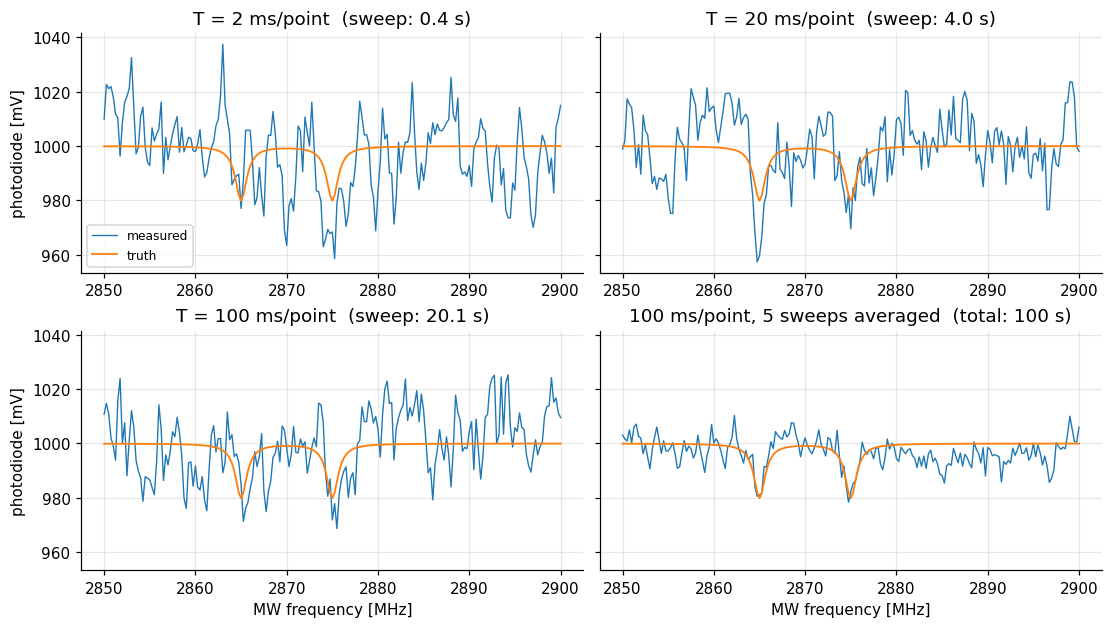

In [6]:
FS_DC = 10_000   # simulation sample rate for DC integration [Hz]

def dc_sweep(freqs, T, rng, **noise_kw):
    '''Step-and-dwell sweep: at each frequency, average the noisy PL for T seconds.
    Noise is generated as ONE continuous trace across the whole sweep, so slow
    1/f wander drifts *through* the sweep like it does in the lab.'''
    npt = int(round(T * FS_DC))
    noise = make_noise(len(freqs) * npt, FS_DC, rng, **noise_kw)
    noise = noise.reshape(len(freqs), npt)
    return pl_volt(freqs) + noise.mean(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharey=True)
for ax, T in zip(axes.flat[:3], (0.002, 0.020, 0.100)):
    ax.plot(FREQS, 1e3 * dc_sweep(FREQS, T, rng), lw=0.9, color="C0",
            label="measured")
    ax.plot(FREQS, 1e3 * pl_volt(FREQS), color="C1", lw=1.2, label="truth")
    ax.set(title=f"T = {1e3*T:.0f} ms/point  (sweep: {len(FREQS)*T:.1f} s)")

# what we actually do in the lab: average N_SWEEPS full sweeps at 100 ms/point
avg5 = np.mean([dc_sweep(FREQS, 0.100, rng) for _ in range(5)], axis=0)
ax = axes.flat[3]
ax.plot(FREQS, 1e3 * avg5, lw=0.9, color="C0")
ax.plot(FREQS, 1e3 * pl_volt(FREQS), color="C1", lw=1.2)
ax.set(title=f"100 ms/point, 5 sweeps averaged  (total: {5*len(FREQS)*0.1:.0f} s)")
for ax in axes[1]:
    ax.set_xlabel("MW frequency [MHz]")
for ax in axes[:, 0]:
    ax.set_ylabel("photodiode [mV]")
axes.flat[0].legend(loc="lower left", fontsize=8)
plt.show()

> **EXPERIMENT.** One real DC sweep in which every frequency point was
captured as a single 134 ms ADC buffer, then integrated over the first 2, 8, 20
and 100 ms of the *same* buffer (`notebooks/acq_dc_integration_sweep.py`) — so
the four panels share identical noise and differ *only* in integration time.

In [7]:
# === EXPERIMENT: one sweep, four integration times =========================
import csv, os
_p = "tutorial_data/dc_integration_sweep.csv"
if not os.path.exists(_p):
    print("No data yet: run  notebooks/acq_dc_integration_sweep.py  on the lab PC.")
else:
    with open(_p) as fh:
        labels = None
        rows = []
        for line in fh:
            if line.startswith("#"):
                continue
            if line.startswith("freq"):
                labels = [s.strip() for s in line.split(",")[1:]]
                continue
            rows.append([float(x) for x in line.split(",")])
    arr = np.array(rows)
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharey=True)
    for k, ax in enumerate(axes.flat):
        ax.plot(arr[:, 0], 1e3 * arr[:, k + 1], lw=0.8, color="C0")
        ax.set_title("EXPERIMENT: T = " + labels[k].replace("V_", ""))
    for ax in axes[1]:
        ax.set_xlabel("MW frequency [MHz]")
    for ax in axes[:, 0]:
        ax.set_ylabel("photodiode [mV]")
    plt.show()

No data yet: run  notebooks/acq_dc_integration_sweep.py  on the lab PC.


At 2 ms per point the dips are invisible; at 100 ms they emerge — but the
baseline still wanders (that is the $1/f$ noise drifting *through* the sweep, and
it is why the real script measures $\mathrm{PL_{on}}/\mathrm{PL_{off}}$, doubling
the time per point). Averaging 5 full sweeps finally gives a usable spectrum —
for a price of **~100 s of measurement** (and ~10 minutes in the real experiment,
with the MW-off reference and settling included).

## Why not just integrate longer?

For **white** noise, averaging works beautifully. Averaging over $T$ keeps only the
band $B \approx 1/(2T)$ near DC, so the residual noise RMS is

$$\sigma(T) \;=\; w\,\sqrt{B} \;=\; \frac{w}{\sqrt{2T}} \;\propto\; \frac{1}{\sqrt{T}}.$$

Twice the time, $\sqrt2$ less noise. But for $1/f$ noise this **fails**: as you
integrate longer, the band shrinks toward DC, but the noise power *density* in that
band grows as $1/f$ — the two effects cancel and $\sigma(T)$ stops improving. Past
that point, extra integration time is simply wasted.

Let's measure $\sigma(T)$ empirically: repeat a baseline measurement many times at
each $T$ and take the scatter of the results.

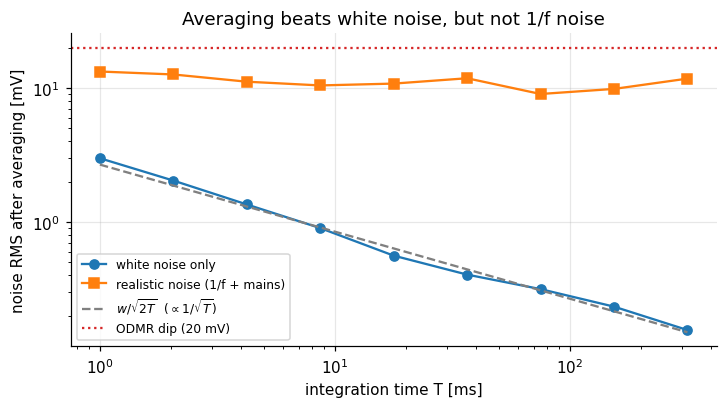

In [8]:
def measured_rms(T, rng, n_rep=60, **noise_kw):
    '''Scatter (std) of n_rep consecutive T-second averages of pure noise.
    One continuous record is chopped into chunks, like consecutive sweep points,
    so slow wander BETWEEN measurements is included.'''
    npt = int(round(T * FS_DC))
    chunks = make_noise(n_rep * npt, FS_DC, rng, **noise_kw).reshape(n_rep, npt)
    return np.std(chunks.mean(axis=1))

T_grid = np.logspace(-3, -0.5, 9)          # 1 ms ... 316 ms
rms_white = [measured_rms(T, rng, f_knee=0.0, mains=()) for T in T_grid]
rms_full  = [measured_rms(T, rng)                        for T in T_grid]

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.loglog(1e3 * T_grid, 1e3 * np.array(rms_white), "o-", label="white noise only")
ax.loglog(1e3 * T_grid, 1e3 * np.array(rms_full), "s-", label="realistic noise (1/f + mains)")
guide = W_ASD / np.sqrt(2 * T_grid)
ax.loglog(1e3 * T_grid, 1e3 * guide, "--", color="gray",
          label=r"$w/\sqrt{2T}$  ($\propto 1/\sqrt{T}$)")
ax.axhline(1e3 * CONTRAST * V0, color="C3", ls=":", label="ODMR dip (20 mV)")
ax.set(xlabel="integration time T [ms]", ylabel="noise RMS after averaging [mV]",
       title="Averaging beats white noise, but not 1/f noise")
ax.legend(fontsize=8)
plt.show()

> **EXPERIMENT.** The same experiment on real noise: 20 contiguous 1.07 s
photodiode records taken off resonance (`notebooks/acq_noise_vs_integration.py`),
sliced into chunks of length $T$; the scatter of the chunk means is the measured
DC noise after integrating for $T$.

In [9]:
# === EXPERIMENT: DC noise vs integration time ==============================
import os
_p = "tutorial_data/noise_vs_T.npz"
if not os.path.exists(_p):
    print("No data yet: run  notebooks/acq_noise_vs_integration.py  on the lab PC.")
else:
    d = np.load(_p)
    fs_, vs = float(d["fs"]), d["v"]
    T_exp = np.array([0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
    rms_exp = []
    for T in T_exp:
        n = int(T * fs_)
        means = [v[i*n:(i+1)*n].mean() for v in vs for i in range(len(v)//n)]
        rms_exp.append(np.std(means))
    rms_exp = np.array(rms_exp)
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.loglog(1e3 * T_exp, 1e3 * rms_exp, "s-", color="C1", label="measured (rig)")
    ax.loglog(1e3 * T_exp, 1e3 * rms_exp[0] * np.sqrt(T_exp[0] / T_exp), "--",
              color="gray", label=r"$\propto 1/\sqrt{T}$ (white-noise law)")
    ax.set(xlabel="integration time T [ms]", ylabel="noise RMS [mV]",
           title="EXPERIMENT: where our rig stops gaining from integration")
    ax.legend(fontsize=8)
    plt.show()

No data yet: run  notebooks/acq_noise_vs_integration.py  on the lab PC.


With white noise alone (blue), integration follows the $1/\sqrt{T}$ law
forever. With realistic noise (orange), the $1/\sqrt{T}$ gain is essentially gone:
whatever the integration time, the result is dominated by $1/f$ wander *between*
measurements, which averaging within a point cannot touch. This is why the real script stops at $T=100$ ms and
instead relies on the MW-on/off ratio and on averaging many sweeps.

### A detail from the real code: mains-clean blocks

`odmr_smcv100b_pc.py` integrates in exact **100 ms blocks**. That is not arbitrary:
100 ms contains *exactly* 5 cycles of 50 Hz (and 15 of 150 Hz), so mains pickup
averages to zero. Integrate for 97 ms instead and part of a mains cycle is left
over, leaking 50 Hz noise into every point:

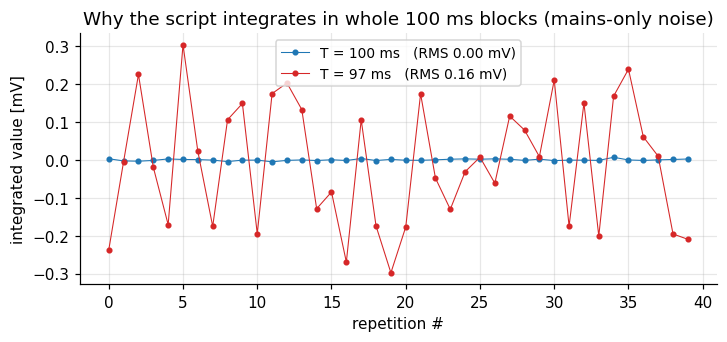

In [10]:
def repeated_means(T, rng, n_rep=40):
    npt = int(round(T * FS_DC))
    return np.array([make_noise(npt, FS_DC, rng, w=1e-6, f_knee=0.0).mean()
                     for _ in range(n_rep)])   # ~only mains, to isolate the effect

fig, ax = plt.subplots(figsize=(6.5, 3))
for T, c in ((0.100, "C0"), (0.097, "C3")):
    m = repeated_means(T, rng)
    ax.plot(1e3 * m, ".-", color=c, lw=0.7,
            label=f"T = {1e3*T:.0f} ms   (RMS {1e3*np.std(m):.2f} mV)")
ax.set(xlabel="repetition #", ylabel="integrated value [mV]",
       title="Why the script integrates in whole 100 ms blocks (mains-only noise)")
ax.legend(fontsize=9)
plt.show()

**Part 1 scorecard.** The DC method works, but it is expensive:

* $T = 100$ ms per point, **plus** another 100 ms with MW off, plus settling —
  about 0.25 s per point. Our real sweep (501 points, 5 sweeps) takes **~10 minutes**.
* Even then, sensitivity is limited by $1/f$ noise and drift, not by the detector.

The fundamental problem: *the measurement band sits at DC, where the noise is
worst.* Both lock-in methods fix exactly this — they **move the measurement to
5 kHz**, onto the quiet white floor, without touching the physics.

---
# Part 2 — Amplitude modulation + lock-in detection

### Intuition first

Imagine you are in a loud party trying to hear one friend. If they speak in a normal
voice (DC), they blend into the murmur. But if you agree beforehand that they will
*chant rhythmically at exactly 5 beats per second*, you can pick their voice out of
the noise — nobody else is doing that rhythm.

AM lock-in ODMR is exactly this trick (`smcv/odmr_lockin_am_pc.py`):

* The SMCV turns its own MW output power up and down **at $f_m = 5$ kHz**
  (internal LF generator, 90 % depth — no extra cabling).
* **Off resonance**, the microwaves do nothing to the NV centres, so the PL is
  steady: the photodiode contains **no 5 kHz tone**.
* **On resonance**, the MW power suppresses the PL — so as the power blinks at
  5 kHz, the PL blinks at 5 kHz. The **amplitude of the 5 kHz tone in the
  photodiode is proportional to the ODMR contrast** $C(f)$.

We have *tagged* our tiny signal with a frequency label where the noise floor is
quiet, and now we just need a receiver tuned to 5 kHz. That receiver is the lock-in.

### The mathematics

The SMCV modulates the MW *amplitude* with depth $m$:
$A(t) = A_0\,[1 + m\cos(\omega_m t)]$, so the MW **power** (what the NVs feel) is

$$p(t) \;\propto\; [1 + m\cos(\omega_m t)]^2
      \;=\; \Bigl(1 + \tfrac{m^2}{2}\Bigr) + 2m\cos(\omega_m t) + \tfrac{m^2}{2}\cos(2\omega_m t).$$

With our linear-response model $V(t) = V_0[1 - C(f)\,p(t)/p_{\max}]$, the
photodiode voltage contains a component **at $\omega_m$** with amplitude

$$\boxed{\,A_1(f) \;=\; V_0\, C(f)\,\frac{2m}{(1+m)^2}\,}$$

— directly proportional to the ODMR line shape $C(f)$. (For $m=0.9$ the prefactor
is $\approx 0.5$: about half the DC dip depth appears as tone amplitude. There is
also a harmless tone at $2\omega_m$ from the $\cos^2$ term.)

**The lock-in (synchronous detector).** To extract "how much $\cos(\omega_m t)$ is
in $v(t)$", multiply by reference oscillations and average over the measurement
time $T$:

$$X = \frac{2}{T}\int_0^T v(t)\cos(\omega_m t)\,dt,\qquad
  Y = \frac{2}{T}\int_0^T v(t)\sin(\omega_m t)\,dt,\qquad
  R = \sqrt{X^2 + Y^2}.$$

Why this works — two lines of trigonometry:

* The signal component $A_1\cos(\omega_m t + \varphi)$ times $\cos(\omega_m t)$
  gives $\tfrac{A_1}{2}[\cos\varphi + \cos(2\omega_m t + \varphi)]$: a **DC term**
  that survives averaging, plus a fast term that dies.
* A noise component at any other frequency $\omega_n$ times $\cos(\omega_m t)$
  gives oscillations at $\omega_n \pm \omega_m$ — **no DC term**, so it averages
  away, *unless* $|\omega_n - \omega_m| \lesssim 1/T$.

So the lock-in is a **bandpass filter of width $\sim 1/T$ centred on $f_m$**, whose
output is translated to DC. You choose where on the noise-PSD your measurement
lives simply by choosing $f_m$ — and we park it at 5 kHz, on the white floor.
Using both $X$ and $Y$ and taking the magnitude $R$ makes the result independent of
the unknown phase $\varphi$, which is why the Red Pitaya needs **no reference
cable** to the SMCV. This is exactly `demodulate()` in `smcv/lockin_common.py`.

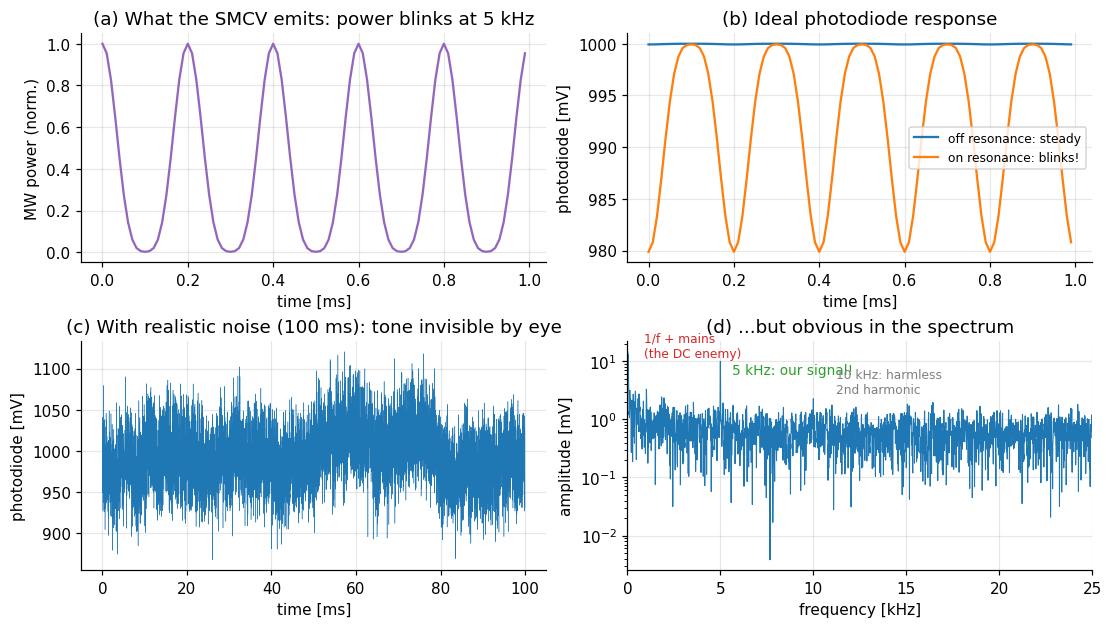

In [11]:
FS_LI = 100_000   # simulation sample rate for lock-in traces [Hz]

def am_power(t, m=AM_DEPTH):
    '''Normalised MW power waveform p(t)/p_max under AM with depth m.'''
    return (1 + m * np.cos(2 * np.pi * F_MOD * t))**2 / (1 + m)**2

def pd_trace_am(f_mhz, T, rng, **noise_kw):
    '''Simulated photodiode voltage during T seconds of AM at MW frequency f.'''
    t = np.arange(int(round(T * FS_LI))) / FS_LI
    v = V0 * (1 - contrast(f_mhz) * am_power(t))
    return t, v + make_noise(len(t), FS_LI, rng, **noise_kw)

T_SHOW = 0.008     # 8 ms, matching the real setup (~N_BUF/fs at decimation 64)
t1 = np.arange(int(0.001 * FS_LI)) / FS_LI     # 1 ms zoom for the clean panels

fig, axes = plt.subplots(2, 2, figsize=(10, 5.6))
ax = axes[0, 0]
ax.plot(1e3 * t1, am_power(t1), color="C4")
ax.set(xlabel="time [ms]", ylabel="MW power (norm.)",
       title="(a) What the SMCV emits: power blinks at 5 kHz")

ax = axes[0, 1]
on  = V0 * (1 - contrast(CENTERS[0]) * am_power(t1))
off = V0 * (1 - contrast(F_START)    * am_power(t1))
ax.plot(1e3 * t1, 1e3 * off, color="C0", label="off resonance: steady")
ax.plot(1e3 * t1, 1e3 * on,  color="C1", label="on resonance: blinks!")
ax.set(xlabel="time [ms]", ylabel="photodiode [mV]",
       title="(b) Ideal photodiode response")
ax.legend(fontsize=8, loc="center right")

# noisy panels use a longer record (100 ms) so the spectrum is well resolved
t100, v_noisy = pd_trace_am(CENTERS[0], 0.100, rng)
ax = axes[1, 0]
ax.plot(1e3 * t100, 1e3 * v_noisy, lw=0.3, color="C0")
ax.set(xlabel="time [ms]", ylabel="photodiode [mV]",
       title="(c) With realistic noise (100 ms): tone invisible by eye")

ax = axes[1, 1]
spec = np.abs(np.fft.rfft((v_noisy - v_noisy.mean()) * np.hanning(len(v_noisy))))
spec *= 2 / np.sum(np.hanning(len(v_noisy)))
fr = np.fft.rfftfreq(len(v_noisy), 1 / FS_LI)
ax.semilogy(1e-3 * fr[1:], 1e3 * spec[1:], lw=0.7, color="C0")
ax.annotate("5 kHz: our signal!", (5.6, 6), color="C2", fontsize=9)
ax.annotate("10 kHz: harmless\n2nd harmonic", (11.2, 2.8), color="gray", fontsize=8)
ax.annotate("1/f + mains\n(the DC enemy)", (0.9, 12), color="C3", fontsize=8)
ax.set(xlabel="frequency [kHz]", ylabel="amplitude [mV]", xlim=(0, 25),
       title="(d) ...but obvious in the spectrum")
plt.show()

> **EXPERIMENT.** Raw photodiode records with AM on
(`notebooks/acq_am_tutorial.py`): on resonance the 5 kHz modulation is really
there — visible directly in the time trace if the contrast is healthy, and
unmistakable in the PSD (with its 2nd harmonic at 10 kHz); off resonance both
vanish. This is panels (b)–(d) of the simulation, on hardware.

In [12]:
# === EXPERIMENT: photodiode output on vs off resonance (AM) ================
import os
_p = "tutorial_data/am_traces.npz"
if not os.path.exists(_p):
    print("No data yet: run  notebooks/acq_am_tutorial.py  on the lab PC.")
else:
    d = np.load(_p)
    fs_ = float(d["fs"])
    on, off = d["on"], d["off"]
    n2ms = int(0.002 * fs_)
    tt = np.arange(n2ms) / fs_
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
    for ax, v, lbl, c in ((axes[0], on[0], f"ON resonance ({float(d['f_on']):.1f} MHz)", "C1"),
                          (axes[1], off[0], f"OFF resonance ({float(d['f_off']):.1f} MHz)", "C0")):
        ax.plot(1e3 * tt, 1e3 * (v[:n2ms] - v[:n2ms].mean()), lw=0.6, color=c)
        ax.set(xlabel="time [ms]", ylabel="photodiode - mean [mV]",
               title="EXPERIMENT: " + lbl)
    ax = axes[2]
    for v_all, lbl, c in ((on, "on resonance", "C1"), (off, "off resonance", "C0")):
        S = np.mean([welch(v - v.mean(), fs=fs_, nperseg=len(v) // 2)[1]
                     for v in v_all], axis=0)
        fr_ = welch(v_all[0] - v_all[0].mean(), fs=fs_, nperseg=len(v_all[0]) // 2)[0]
        ax.semilogy(1e-3 * fr_[1:], S[1:], lw=0.8, color=c, label=lbl)
    ax.axvline(1e-3 * F_MOD, color="C2", ls=":", lw=1)
    ax.axvline(2e-3 * F_MOD, color="gray", ls=":", lw=1)
    ax.set(xlabel="frequency [kHz]", xlim=(0, 25),
           ylabel=r"PSD [V$^2$/Hz]", title="EXPERIMENT: PSD, tone + 2nd harmonic")
    ax.legend(fontsize=8)
    plt.show()

No data yet: run  notebooks/acq_am_tutorial.py  on the lab PC.


Panel (c) vs (d) is the magic of frequency tagging: a tone that is
completely invisible in the time trace stands proudly above the noise floor in the
spectrum, because *all of it* is concentrated in one frequency bin, while the noise
is spread over the whole band.

Now the lock-in itself. Below is the exact demodulator from
`smcv/lockin_common.py` (a Hann window is applied before averaging — it suppresses
leakage from the edges of the finite record; conceptually it is still just the
average of $v \times \cos$).

lock-in R on  resonance: 9.12 mV
lock-in R off resonance: 2.38 mV


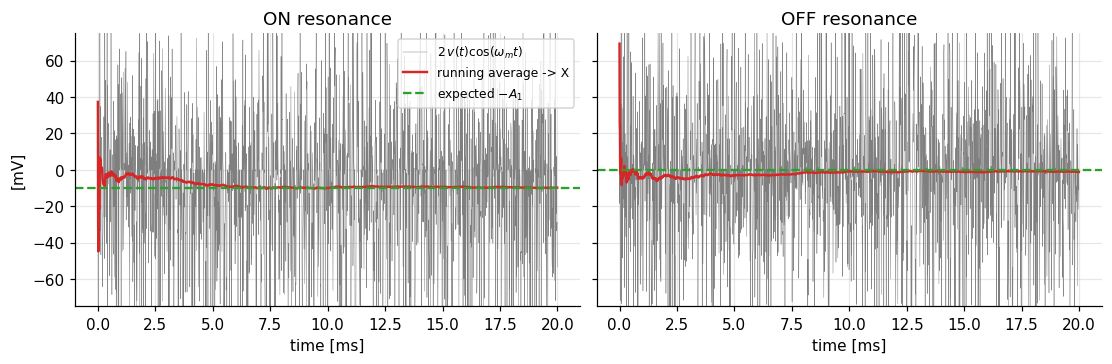

In [13]:
def demodulate(v, fs, f_mod):
    '''Magnitude lock-in R = sqrt(X^2 + Y^2) -- verbatim from smcv/lockin_common.py.'''
    n = len(v)
    t = np.arange(n) / fs
    w = np.hanning(n)
    norm = np.sum(w)
    x = 2.0 * np.sum(v * np.cos(2 * np.pi * f_mod * t) * w) / norm
    y = 2.0 * np.sum(v * np.sin(2 * np.pi * f_mod * t) * w) / norm
    return float(np.hypot(x, y))

# --- watch the mixing + averaging converge, on and off resonance ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, f_mw, lbl in ((axes[0], CENTERS[0], "ON resonance"),
                      (axes[1], F_START,   "OFF resonance")):
    tt, v = pd_trace_am(f_mw, 0.02, rng)
    prod = 2 * (v - v.mean()) * np.cos(2 * np.pi * F_MOD * tt)
    run  = np.cumsum(prod) / np.arange(1, len(prod) + 1)   # running average of v*cos
    ax.plot(1e3 * tt, 1e3 * prod, lw=0.3, color="C7", label=r"$2\,v(t)\cos(\omega_m t)$")
    ax.plot(1e3 * tt, 1e3 * run, color="C3", lw=1.6, label="running average -> X")
    ax.axhline(-1e3 * V0 * contrast(f_mw) * 2 * AM_DEPTH / (1 + AM_DEPTH)**2,
               color="C2", ls="--", label="expected $-A_1$")
    ax.set(xlabel="time [ms]", title=lbl, ylim=(-75, 75))   # zoom: grey clips, red visible
axes[0].set_ylabel("[mV]")
axes[0].legend(fontsize=8, loc="upper right")
print(f"lock-in R on  resonance: {1e3*demodulate(pd_trace_am(CENTERS[0], T_SHOW, rng)[1], FS_LI, F_MOD):.2f} mV")
print(f"lock-in R off resonance: {1e3*demodulate(pd_trace_am(F_START,   T_SHOW, rng)[1], FS_LI, F_MOD):.2f} mV")
plt.show()

The grey trace ($v\times\cos$) looks like noise, but its *average* (red)
converges within milliseconds: to $-A_1 \approx -10$ mV on resonance, to
$\approx 0$ off resonance. That average **is** the lock-in output. (Why the minus
sign? The PL tone is *inverted* — PL drops when the MW power peaks — so it arrives
$180°$ out of phase with our reference. Taking the magnitude $R=\sqrt{X^2+Y^2}$
discards exactly this kind of unknowable phase.)

### The full AM sweep — 8 ms per point

Sweep the MW frequency and record $R$ at each point, exactly like the real script.
For a brutal comparison we also run the **DC method with the same 8 ms per point**:
same total measurement time, same noise, same physics.

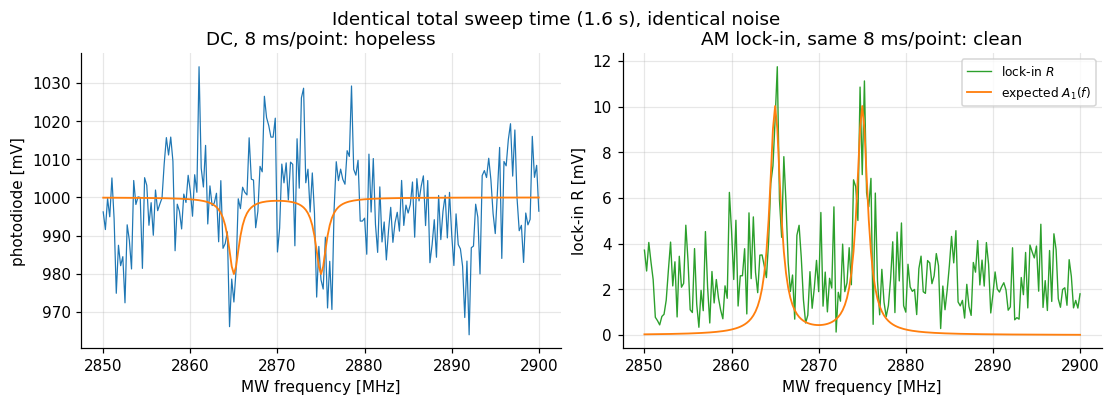

In [14]:
def am_sweep(freqs, T, rng, **noise_kw):
    '''Lock-in AM sweep: at each MW frequency, demodulate T seconds of PD signal.'''
    npt = int(round(T * FS_LI))
    t = np.arange(npt) / FS_LI
    p = am_power(t)
    noise = make_noise(len(freqs) * npt, FS_LI, rng, **noise_kw).reshape(len(freqs), npt)
    return np.array([demodulate(V0 * (1 - contrast(f) * p) + n, FS_LI, F_MOD)
                     for f, n in zip(freqs, noise)])

R_am  = am_sweep(FREQS, T_SHOW, rng)
V_dc  = dc_sweep(FREQS, T_SHOW, rng)
A1_th = V0 * contrast(FREQS) * 2 * AM_DEPTH / (1 + AM_DEPTH)**2

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(FREQS, 1e3 * V_dc, lw=0.8, color="C0")
axes[0].plot(FREQS, 1e3 * pl_volt(FREQS), color="C1", lw=1.2)
axes[0].set(xlabel="MW frequency [MHz]", ylabel="photodiode [mV]",
            title=f"DC, {1e3*T_SHOW:.0f} ms/point: hopeless")
axes[1].plot(FREQS, 1e3 * R_am, lw=0.9, color="C2", label="lock-in $R$")
axes[1].plot(FREQS, 1e3 * A1_th, color="C1", lw=1.2, label="expected $A_1(f)$")
axes[1].set(xlabel="MW frequency [MHz]", ylabel="lock-in R [mV]",
            title=f"AM lock-in, same {1e3*T_SHOW:.0f} ms/point: clean")
axes[1].legend(fontsize=8)
fig.suptitle(f"Identical total sweep time ({len(FREQS)*T_SHOW:.1f} s), identical noise", y=1.04)
plt.show()

> **EXPERIMENT.** The same head-to-head on the rig: the 8 ms column of the
DC sweep from `acq_dc_integration_sweep.py` against the AM lock-in sweep at
~8 ms/point from `acq_am_tutorial.py` — equal time per point, same setup, same
session.

In [15]:
# === EXPERIMENT: DC vs AM lock-in at ~8 ms per point =======================
import csv, os
_pd, _pa = "tutorial_data/dc_integration_sweep.csv", "tutorial_data/am_sweep.csv"
if not (os.path.exists(_pd) and os.path.exists(_pa)):
    print("No data yet: run  notebooks/acq_dc_integration_sweep.py  and "
          "notebooks/acq_am_tutorial.py  on the lab PC.")
else:
    def _load(path):
        out = []
        for row in csv.reader(open(path)):
            if row and not row[0].startswith("#") and not row[0].startswith("freq"):
                out.append([float(x) for x in row])
        return np.array(out)
    dc, am = _load(_pd), _load(_pa)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    axes[0].plot(dc[:, 0], 1e3 * dc[:, 2], lw=0.8, color="C0")   # V_8ms column
    axes[0].set(xlabel="MW frequency [MHz]", ylabel="photodiode [mV]",
                title="EXPERIMENT: DC, 8 ms/point")
    axes[1].plot(am[:, 0], 1e3 * am[:, 1], lw=0.9, color="C2")
    axes[1].set(xlabel="MW frequency [MHz]", ylabel="lock-in R [mV]",
                title="EXPERIMENT: AM lock-in, ~8 ms/point")
    plt.show()

No data yet: run  notebooks/acq_dc_integration_sweep.py  and notebooks/acq_am_tutorial.py  on the lab PC.


Same 8 ms per point, same noise generator — and the lock-in sees both lines
clearly while DC sees nothing. Two remarks:

* The ODMR line appears as a **peak** (in $R$, which is $\geq 0$), not a dip: off
  resonance there is no 5 kHz tone, so $R\approx$ the noise floor.
* The baseline is *flat*: the $1/f$ wander that bent the DC baseline lives at low
  frequency and simply does not pass the 5 kHz filter. Laser drift, mains — all
  gone. This is also why the AM script needs **no MW-off reference point**
  (another factor of 2 in speed).

### Noise rejection, quantified

The lock-in output noise is set by the PSD *at 5 kHz* times the detection bandwidth
$\sim 1/T$, i.e. $\sigma_{\rm lockin}(T) \approx w\sqrt{1/T}$ — pure white-noise
scaling, because the white floor is all there is at 5 kHz. Repeat the
noise-vs-integration-time experiment from Part 1, now for both methods:

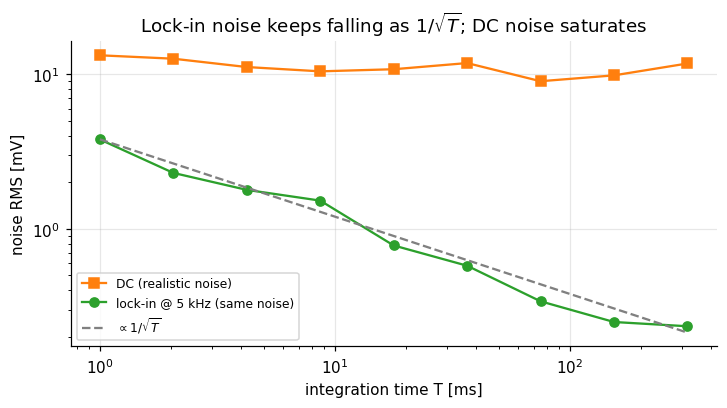

In [16]:
def lockin_noise_rms(T, rng, n_rep=60):
    '''Scatter of consecutive lock-in readings of pure noise (off resonance).'''
    npt = int(round(T * FS_LI))
    chunks = make_noise(n_rep * npt, FS_LI, rng).reshape(n_rep, npt)
    return np.std([demodulate(c, FS_LI, F_MOD) for c in chunks])

rms_lockin = [lockin_noise_rms(T, rng) for T in T_grid]

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.loglog(1e3 * T_grid, 1e3 * np.array(rms_full), "s-", color="C1",
          label="DC (realistic noise)")
ax.loglog(1e3 * T_grid, 1e3 * np.array(rms_lockin), "o-", color="C2",
          label="lock-in @ 5 kHz (same noise)")
ax.loglog(1e3 * T_grid, 1e3 * W_ASD / np.sqrt(T_grid), "--", color="gray",
          label=r"$\propto 1/\sqrt{T}$")
ax.set(xlabel="integration time T [ms]", ylabel="noise RMS [mV]",
       title="Lock-in noise keeps falling as $1/\sqrt{T}$; DC noise saturates")
ax.legend(fontsize=8)
plt.show()

> **EXPERIMENT.** The same comparison from real data: the off-resonance
records of `acq_noise_vs_integration.py` are sliced into chunks of length $T$
and processed both ways — plain mean (DC) and lock-in demodulation at 5 kHz —
so the two curves see *identical* noise. This is the measured version of the
noise-rejection plot above.

In [17]:
# === EXPERIMENT: DC vs lock-in noise, same data ============================
import os
_p = "tutorial_data/noise_vs_T.npz"
if not os.path.exists(_p):
    print("No data yet: run  notebooks/acq_noise_vs_integration.py  on the lab PC.")
else:
    d = np.load(_p)
    fs_, vs, fmod_ = float(d["fs"]), d["v"], float(d["f_mod"])
    T_exp = np.array([0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
    rms_dc, rms_li = [], []
    for T in T_exp:
        n = int(T * fs_)
        chunks = [v[i*n:(i+1)*n] for v in vs for i in range(len(v)//n)]
        rms_dc.append(np.std([c.mean() for c in chunks]))
        rms_li.append(np.std([demodulate(c, fs_, fmod_) for c in chunks]))
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.loglog(1e3 * T_exp, 1e3 * np.array(rms_dc), "s-", color="C1",
              label="DC (chunk means)")
    ax.loglog(1e3 * T_exp, 1e3 * np.array(rms_li), "o-", color="C2",
              label=f"lock-in @ {fmod_/1e3:.0f} kHz (same chunks)")
    ax.loglog(1e3 * T_exp, 1e3 * rms_li[0] * np.sqrt(T_exp[0] / T_exp), "--",
              color="gray", label=r"$\propto 1/\sqrt{T}$")
    ax.set(xlabel="integration time T [ms]", ylabel="noise RMS [mV]",
           title="EXPERIMENT: noise rejection on the rig")
    ax.legend(fontsize=8)
    plt.show()

No data yet: run  notebooks/acq_noise_vs_integration.py  on the lab PC.


**This plot is the answer to "why can lock-in use shorter integration
times".** Two separate effects stack:

1. **Less noise at any given $T$**: at 8 ms the lock-in already sits several times
   below the DC curve, because its band contains only the white floor — no $1/f$,
   no mains.
2. **Integration keeps paying off**: the lock-in follows $1/\sqrt{T}$ indefinitely,
   so if you ever need more SNR, longer $T$ (or more sweeps) actually delivers it.
   The DC curve is flat there — extra time buys nothing.

In our real setup: DC needs $2\times100$ ms + settling $\approx 0.25$ s/point; the
lock-in needs $\approx 8$ ms + 10 ms settling $\approx 0.02$ s/point, with *better*
noise. That is the promised ~25× speed-up at equal-or-better quality — no cheating,
just moving the measurement out of the noisy neighbourhood.

---
# Part 3 — Frequency modulation + lock-in detection

### Intuition first

AM wiggles the *power*. FM (`smcv/odmr_lockin_fm_pc.py`) keeps the power constant
and wiggles the **frequency**: the SMCV dithers its output frequency by a small
deviation $\Delta$ around each sweep point, at the same $f_m = 5$ kHz.

Think of the ODMR dip as a valley and the instantaneous MW frequency as your
position while you rock left-right by $\pm\Delta$:

* On the **flat background** far from the line: rocking changes nothing — the PL is
  steady. No 5 kHz tone.
* On a **slope** of the dip: rocking left-right moves you up-down. The PL oscillates
  at 5 kHz, and the *steeper the slope, the bigger the oscillation*.
* Exactly at the **bottom** (line centre): both sides of the rock go *up* by the
  same tiny amount — the PL wiggles at **10 kHz** (twice per rock), and the 5 kHz
  component vanishes.

So the 5 kHz amplitude maps out the **slope** — the *derivative* of the ODMR line.

### The mathematics

The instantaneous frequency is $f(t) = f_c + \Delta\cos(\omega_m t)$. Taylor-expand
the PL around $f_c$ for small $\Delta$:

$$V\bigl(f(t)\bigr) \;\approx\; V(f_c)
   \;+\; \underbrace{V'(f_c)\,\Delta}_{A_1}\cos(\omega_m t)
   \;+\; \frac{V''(f_c)\,\Delta^2}{4}\bigl[1 + \cos(2\omega_m t)\bigr] + \dots$$

The component at $\omega_m$ has amplitude $A_1 = \Delta\,V'(f_c)$ — the lock-in
directly measures the **derivative of the spectrum**, scaled by the deviation.
(And the $2\omega_m$ term $\propto V''$ explains the frequency-doubled wiggle at
the line centre.)

One subtlety, straight from the real script's docstring: our lock-in computes the
phase-independent **magnitude** $R = |A_1| \propto |V'(f)|$. A derivative is signed;
its absolute value folds the negative lobe up. So each ODMR line appears as **two
lobes with a sharp null at the line centre**. (The signed, dispersive version needs
a phase reference on Red Pitaya IN2 — that is `odmr_lockin_fm_deriv_pc.py`.)

**Terminology note for our rig.** The *modulation* here is real: the SMCV
frequency-modulates its own output in hardware. What is *virtual* is the
**demodulation** — the Red Pitaya never receives a reference copy of the
modulation waveform (the SMCV100B cannot output its LF signal), so the software
lock-in computes the phase-independent magnitude $R$ against the *known*
modulation frequency. A **phase-referenced** demodulation, which preserves the
sign of the derivative, is not currently realisable on our hardware; it appears
at the end of this section as simulation only.

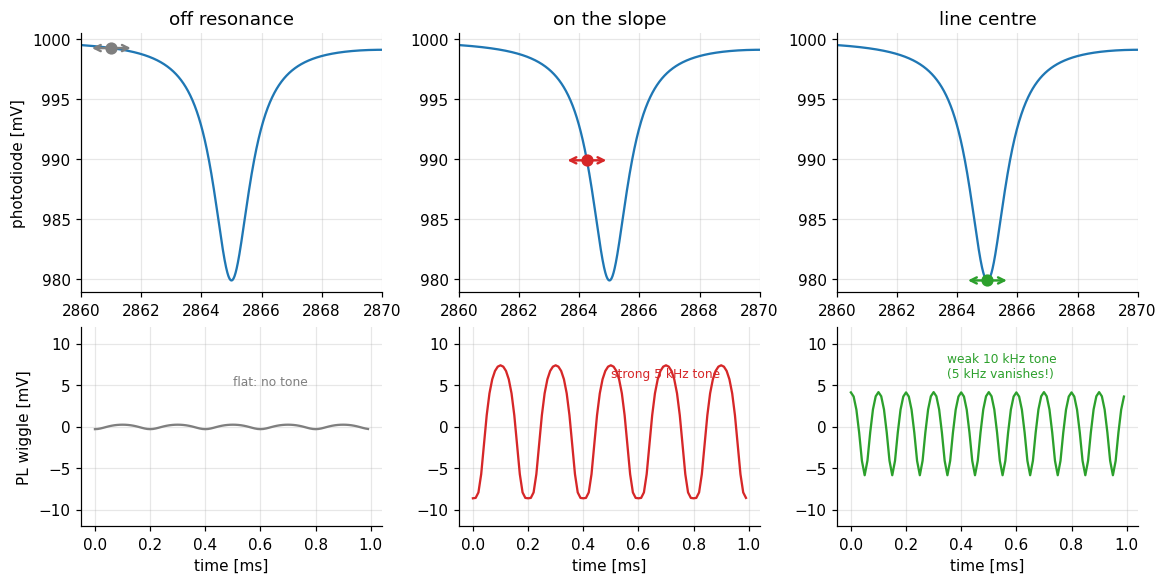

In [18]:
# --- the rocking intuition, drawn ---
f_fine = np.linspace(2860, 2870, 1200)
pts = ((2861.0, "off resonance", "C7"),
       (CENTERS[0] - FWHM / 2, "on the slope", "C3"),
       (CENTERS[0], "line centre", "C2"))

fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.2), height_ratios=(1.3, 1))
for k, (fc, lbl, c) in enumerate(pts):
    ax = axes[0, k]
    ax.plot(f_fine, 1e3 * pl_volt(f_fine), color="C0")
    ax.plot(fc, 1e3 * pl_volt(fc), "o", color=c, ms=7)
    ax.annotate("", (fc + FM_DEV, 1e3 * pl_volt(fc)), (fc - FM_DEV, 1e3 * pl_volt(fc)),
                arrowprops=dict(arrowstyle="<->", color=c, lw=1.6))
    ax.set(title=lbl, xlim=(2860, 2870))
    if k == 0:
        ax.set_ylabel("photodiode [mV]")

    # ideal PL time trace while dithering around fc
    tt = np.arange(int(0.001 * FS_LI)) / FS_LI          # 1 ms = 5 mod cycles
    v = pl_volt(fc + FM_DEV * np.cos(2 * np.pi * F_MOD * tt))
    ax = axes[1, k]
    ax.plot(1e3 * tt, 1e3 * (v - v.mean()), color=c)
    ax.set(xlabel="time [ms]", ylim=(-12, 12))
    if k == 0:
        ax.set_ylabel("PL wiggle [mV]")
axes[1, 0].text(0.5, 5, "flat: no tone", fontsize=8, color="C7")
axes[1, 1].text(0.5, 6, "strong 5 kHz tone", fontsize=8, color="C3")
axes[1, 2].text(0.35, 6, "weak 10 kHz tone\n(5 kHz vanishes!)", fontsize=8, color="C2")
plt.show()

> **EXPERIMENT.** The rocking intuition on hardware
(`notebooks/acq_fm_tutorial.py`): raw photodiode records parked off resonance,
on a lobe slope, and at the null. Look for no tone / a 5 kHz tone / a doubled
10 kHz wiggle respectively — the PSDs make the frequency doubling at the centre
obvious even when the time traces are noisy.

In [19]:
# === EXPERIMENT: FM photodiode records off / slope / null ==================
import os
_p = "tutorial_data/fm_traces.npz"
if not os.path.exists(_p):
    print("No data yet: run  notebooks/acq_fm_tutorial.py  on the lab PC.")
else:
    d = np.load(_p)
    fs_ = float(d["fs"])
    n15 = int(0.0015 * fs_)
    tt = np.arange(n15) / fs_
    fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.4))
    for k, (tag, c) in enumerate((("off", "C7"), ("slope", "C3"), ("null", "C2"))):
        v_all = d[tag]
        v = v_all[0]
        axes[0, k].plot(1e3 * tt, 1e3 * (v[:n15] - v[:n15].mean()), lw=0.7, color=c)
        axes[0, k].set_title(f"EXPERIMENT: {tag} ({float(d['f_'+tag]):.2f} MHz)")
        S = np.mean([welch(x - x.mean(), fs=fs_, nperseg=len(x) // 2)[1]
                     for x in v_all], axis=0)
        fr_ = welch(v - v.mean(), fs=fs_, nperseg=len(v) // 2)[0]
        axes[1, k].semilogy(1e-3 * fr_[1:], S[1:], lw=0.7, color=c)
        axes[1, k].axvline(1e-3 * F_MOD, color="C2", ls=":", lw=1)
        axes[1, k].axvline(2e-3 * F_MOD, color="gray", ls=":", lw=1)
        axes[1, k].set(xlabel="frequency [kHz]", xlim=(0, 25))
    axes[0, 0].set_ylabel("photodiode - mean [mV]")
    axes[1, 0].set_ylabel(r"PSD [V$^2$/Hz]")
    plt.show()

No data yet: run  notebooks/acq_fm_tutorial.py  on the lab PC.


Exactly as promised: no tone on the flat, a strong 5 kHz tone on the slope,
and a small frequency-doubled wiggle at the centre. Now run the full FM sweep with
noise — same 8 ms per point, same demodulator as AM:

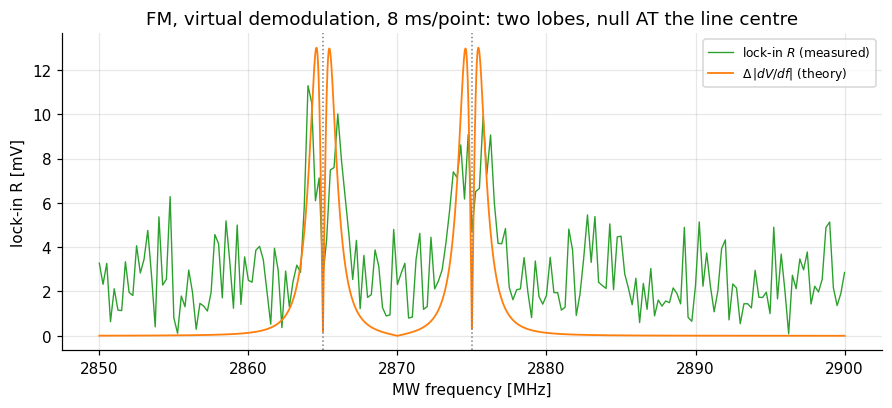

In [20]:
def fm_sweep(freqs, T, rng, dev=FM_DEV, signed=False, **noise_kw):
    """Lock-in FM sweep. signed=False -> magnitude R: our VIRTUAL, phase-free
    demodulation (what the rig does). signed=True -> phase-sensitive X, which
    needs a hardware phase reference -- simulation only on our setup."""
    npt = int(round(T * FS_LI))
    t = np.arange(npt) / FS_LI
    dither = dev * np.cos(2 * np.pi * F_MOD * t)
    noise = make_noise(len(freqs) * npt, FS_LI, rng, **noise_kw).reshape(len(freqs), npt)
    out = []
    for f, n in zip(freqs, noise):
        v = pl_volt(f + dither) + n
        if signed:   # in-phase component only; we know the phase in a simulation
            w = np.hanning(npt)
            out.append(2 * np.sum((v - v.mean()) * np.cos(2 * np.pi * F_MOD * t) * w)
                       / np.sum(w))
        else:
            out.append(demodulate(v, FS_LI, F_MOD))
    return np.array(out)

R_fm = fm_sweep(FREQS, T_SHOW, rng)

# analytic |derivative| for comparison: A1 = dev * |dV/df|
f_fine = np.linspace(F_START, F_STOP, 4000)
dVdf = np.gradient(pl_volt(f_fine), f_fine)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(FREQS, 1e3 * R_fm, lw=0.9, color="C2", label="lock-in $R$ (measured)")
ax.plot(f_fine, 1e3 * FM_DEV * np.abs(dVdf), color="C1", lw=1.2,
        label=r"$\Delta\,|dV/df|$ (theory)")
for c in CENTERS:
    ax.axvline(c, color="gray", ls=":", lw=1)
ax.set(xlabel="MW frequency [MHz]", ylabel="lock-in R [mV]",
       title=f"FM, virtual demodulation, {1e3*T_SHOW:.0f} ms/point: "
             "two lobes, null AT the line centre")
ax.legend(fontsize=8)
plt.show()

> **EXPERIMENT.** The measured FM lock-in sweep at ~8 ms/point
(`notebooks/acq_fm_tutorial.py`): each resonance appears as two lobes with a
null at its centre, exactly as the simulation predicts.

In [21]:
# === EXPERIMENT: FM lock-in sweep ==========================================
import csv, os
_p = "tutorial_data/fm_sweep.csv"
if not os.path.exists(_p):
    print("No data yet: run  notebooks/acq_fm_tutorial.py  on the lab PC.")
else:
    fx, ry = [], []
    for row in csv.reader(open(_p)):
        if row and not row[0].startswith("#") and not row[0].startswith("freq"):
            fx.append(float(row[0])); ry.append(float(row[1]))
    fig, ax = plt.subplots(figsize=(8, 3.4))
    ax.plot(fx, 1e3 * np.array(ry), lw=0.9, color="C2")
    ax.set(xlabel="MW frequency [MHz]", ylabel="lock-in R [mV]",
           title="EXPERIMENT: FM magnitude sweep, ~8 ms/point")
    plt.show()

No data yet: run  notebooks/acq_fm_tutorial.py  on the lab PC.


The measured curves sit right on the analytic derivative. Why is a
derivative shape *useful*, not just cute?

* **Pinpointing the line centre.** The dip minimum of a broad, noisy line is a shallow
  extremum — hard to locate. The FM null (or the signed zero-crossing) is a steep
  feature: tiny shifts of the resonance produce a large, sign-carrying change in the
  signal. Ideal for tracking Zeeman shifts, i.e. magnetometry — and it is why we use
  the FM mode for small-splitting magnet scans.
* **Built-in background rejection.** Any *flat or slowly-sloping* background —
  laser power level, detector offset, broad fluorescence drift — has (nearly) zero
  derivative and simply vanishes from the FM signal. AM still carries the background
  through its overall scale; FM does not even see it.
* Noise-wise, FM enjoys **exactly the same advantages as AM** (detection at 5 kHz on
  the white floor, $1/\sqrt{T}$ scaling, 8 ms points) — it is the same lock-in, only
  the encoding differs.

### Choosing the deviation $\Delta$ (why config says 2 MHz)

The Taylor expansion assumed $\Delta$ small. Larger $\Delta$ gives more signal
($A_1 \propto \Delta$) — until $\Delta$ approaches the linewidth and the dither
averages over the whole line, **broadening** the measured shape. The optimum is
around $\Delta \approx \Gamma/2$; our config's 2 MHz ($> \Gamma = 1.5$ MHz) trades
some sharpness for signal:

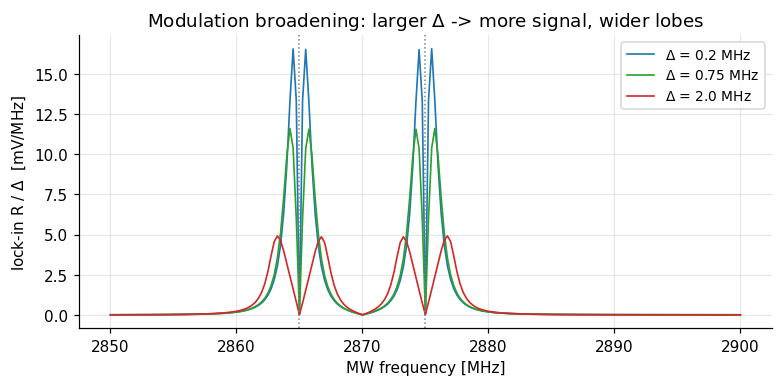

In [22]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for dev, c in ((0.2, "C0"), (0.75, "C2"), (2.0, "C3")):
    R = fm_sweep(FREQS, T_SHOW, rng, dev=dev, w=1e-9, f_knee=0, mains=())  # noise-free
    ax.plot(FREQS, 1e3 * R / dev, color=c, lw=1.1,
            label=f"$\\Delta$ = {dev} MHz")
for c in CENTERS:
    ax.axvline(c, color="gray", ls=":", lw=1)
ax.set(xlabel="MW frequency [MHz]", ylabel=r"lock-in R / $\Delta$  [mV/MHz]",
       title=r"Modulation broadening: larger $\Delta$ -> more signal, wider lobes")
ax.legend(fontsize=9)
plt.show()

### Simulation only: phase-referenced (signed) FM

Everything above used our **virtual, phase-free** demodulation: the magnitude
$R=\sqrt{X^2+Y^2}$, computed against internally generated cosine/sine at the
*known* $f_m$, needing no cable between the SMCV and the Red Pitaya. The price
is the lost **sign**: $R \propto |V'(f)|$ folds the negative lobe up.

A **phase-referenced** lock-in — one that receives the actual modulation
waveform as a reference — recovers the signed, *dispersive* derivative, whose
zero-crossing marks the line centre with a sign that tells you which way you
drifted. **We cannot realise this experimentally at present**: our SMCV100B
cannot output its internal LF modulation signal, so there is nothing to connect
to Red Pitaya IN2 (this is what `smcv/odmr_lockin_fm_deriv_pc.py` would need).
The cell below therefore shows the signed version in *simulation only* — in the
simulation we are omniscient and know the modulation phase exactly.

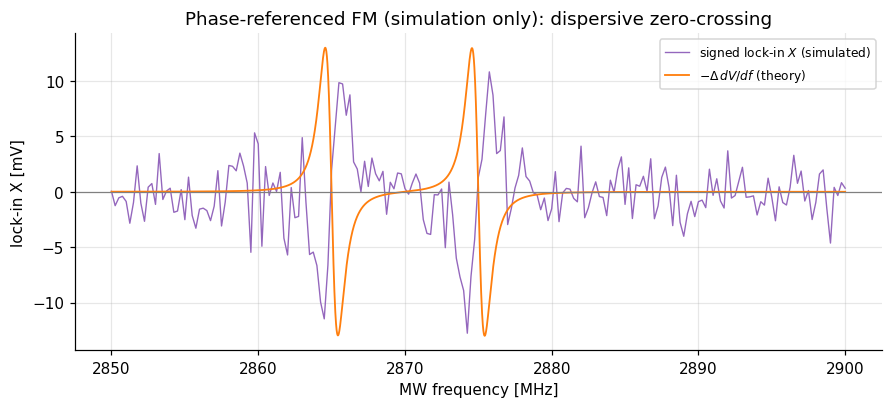

In [23]:
# --- SIMULATION ONLY: signed (phase-referenced) FM demodulation ------------
X_fm = fm_sweep(FREQS, T_SHOW, rng, signed=True)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(FREQS, 1e3 * X_fm, lw=0.9, color="C4", label="signed lock-in $X$ (simulated)")
ax.plot(f_fine, -1e3 * FM_DEV * dVdf, color="C1", lw=1.2,
        label=r"$-\Delta\,dV/df$ (theory)")
ax.axhline(0, color="gray", lw=0.8)
ax.set(xlabel="MW frequency [MHz]", ylabel="lock-in X [mV]",
       title="Phase-referenced FM (simulation only): dispersive zero-crossing")
ax.legend(fontsize=8)
plt.show()

---
# Putting it all together

One final, honest comparison. Every panel below uses the **same noise model**; the
two lock-in methods get 8 ms per point, DC gets 8 ms in the first panel and its
usual 100 ms in the second.

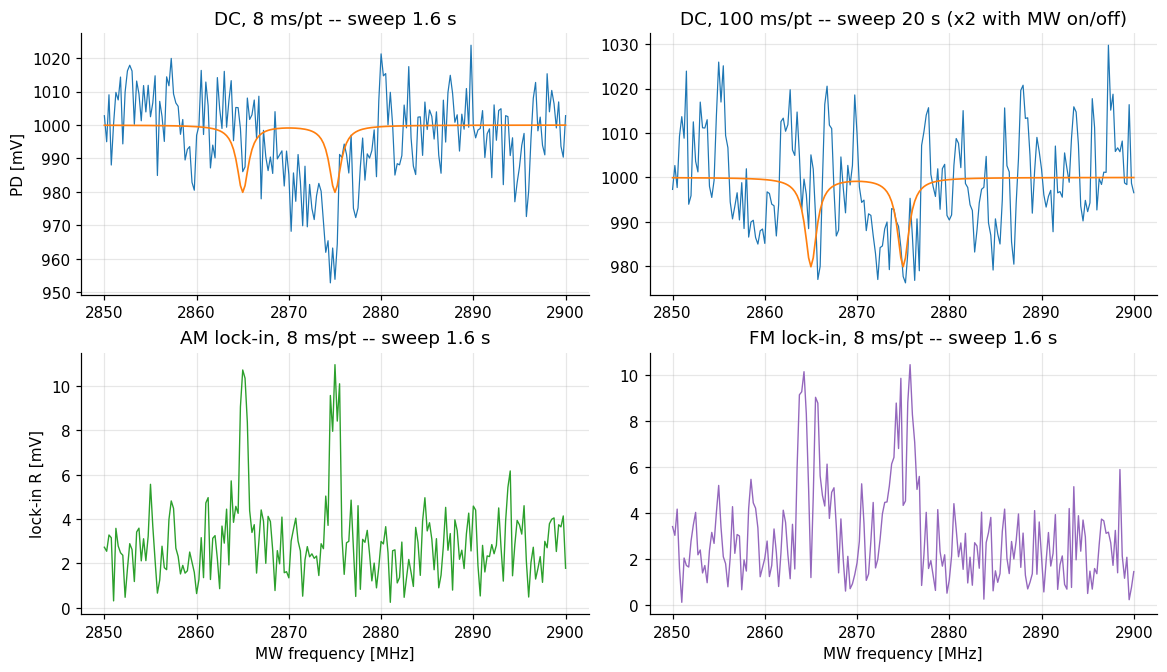

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 6))

ax = axes[0, 0]
ax.plot(FREQS, 1e3 * dc_sweep(FREQS, 0.008, rng), lw=0.8, color="C0")
ax.plot(FREQS, 1e3 * pl_volt(FREQS), color="C1", lw=1.1)
ax.set(ylabel="PD [mV]", title=f"DC, 8 ms/pt -- sweep {len(FREQS)*0.008:.1f} s")

ax = axes[0, 1]
ax.plot(FREQS, 1e3 * dc_sweep(FREQS, 0.100, rng), lw=0.8, color="C0")
ax.plot(FREQS, 1e3 * pl_volt(FREQS), color="C1", lw=1.1)
ax.set(title=f"DC, 100 ms/pt -- sweep {len(FREQS)*0.1:.0f} s (x2 with MW on/off)")

ax = axes[1, 0]
ax.plot(FREQS, 1e3 * am_sweep(FREQS, 0.008, rng), lw=0.9, color="C2")
ax.set(xlabel="MW frequency [MHz]", ylabel="lock-in R [mV]",
       title=f"AM lock-in, 8 ms/pt -- sweep {len(FREQS)*0.008:.1f} s")

ax = axes[1, 1]
ax.plot(FREQS, 1e3 * fm_sweep(FREQS, 0.008, rng), lw=0.9, color="C4")
ax.set(xlabel="MW frequency [MHz]",
       title=f"FM lock-in, 8 ms/pt -- sweep {len(FREQS)*0.008:.1f} s")
plt.show()

## Summary

| | **DC** (`odmr_smcv100b_pc.py`) | **AM lock-in** (`odmr_lockin_am_pc.py`) | **FM lock-in** (`odmr_lockin_fm_pc.py`) |
|---|---|---|---|
| What is modulated | nothing | MW power, 90 % depth @ 5 kHz | MW frequency, ±2 MHz @ 5 kHz |
| What you record | mean PL voltage | tone amplitude $R \propto C(f)$ | tone amplitude $R \propto |C'(f)|$ |
| Line shape | dip | peak | two lobes, **null at centre** |
| Noise band | 0 … 1/T Hz (1/f + mains!) | ~1/T wide around 5 kHz (white floor) | same as AM |
| Time per point | 2 × 100 ms + settle | ~8 ms + settle | ~8 ms + settle |
| Background/drift | needs MW-on/off ratio | rejected by the 5 kHz filter | rejected **and** flat backgrounds give zero |
| Best for | absolute PL level, first look | fast, clean spectra | precise line centres (magnetometry) |

**The two take-home messages, one last time:**

1. **Noise rejection.** Noise lives mostly near DC ($1/f$, drift, mains). Modulating
   at $f_m = 5$ kHz moves the signal to a quiet part of the spectrum, and the
   lock-in is a narrow bandpass ($\sim 1/T$ wide) parked right there. The $1/f$
   mountain and the mains spikes never enter the measurement.
2. **Speed.** Because the noise floor at 5 kHz is low *and white*, a few
   milliseconds of integration already gives a clean point, and extra averaging
   keeps improving as $1/\sqrt{T}$ (it saturates for DC). Plus, the flat lock-in
   baseline removes the need for the MW-off reference — another factor of two.

### Practical tips for the real setup

* **Choosing $f_m$**: above the $1/f$ knee, away from mains harmonics (5000 Hz is
  a multiple of 50 Hz, but mains *harmonics* that high are negligible), and well
  within the photodiode/ADC bandwidth. A few kHz is the sweet spot for us.
* The Red Pitaya demodulates at a **fixed** $f_m$ (`demodulate()` in
  `lockin_common.py`) — so the LF frequency dialled into the SMCV *must* match
  `config.json → lockin.f_mod_hz`, or the bandpass sits next to the tone and you
  measure nothing. (Off resonance there is no tone at all, which is why the script
  cannot auto-detect it — see the comments in `lockin_common.py`.)
* $R \ge 0$ always: the noise floor makes the off-resonance baseline sit at a small
  positive value, not zero. That is not an offset error, it is the rectified noise.
* AM: watch the peak-envelope power — carrier +16 dBm with 90 % depth would exceed
  the SMCV's maximum (the script warns about this).
* FM: deviation $\approx$ half the linewidth for sharp lobes; more if you need raw
  signal. The null between the lobes marks the line centre either way.

*Where to go next:* run `smcv/odmr_lockin_am_pc.py` and compare a real sweep with
Part 2, or dig into `analysis/nv_odmr_sim.py` for the full 8-line NV physics under
an arbitrary magnetic field.